# S-curve 기반 탄소집약도 동적 모델링 Framework

**목적**: 시트 `학술제시트_517.xlsx`의 `5. 통합` 시트 **B43 (g_decarb = 0.04 고정 상수)** 를 S-curve 기반 동적 함수로 대체.

**산출물**:
- 47사 × 31개년 (t=0..30) `ρ_i(t)` 매트릭스
- 47사 × 31개년 `g_decarb,i(t)` 매트릭스 (시트에 직접 plug-in)
- 47사 × 31개년 `A_i(t)` 누적 도입률 매트릭스

**핵심 변경**: 시트의 단일 값 `(1-0.04)^t` 적용 방식을 → **기업별, 시점별 다른 값** 적용으로 전환.

---
## 1. 수식 체계

### Step 1. 누적 녹색기술 도입률 (Logistic S-curve)

$$A_i(t) = \frac{A_{\max,i}}{1 + \exp(-k_i \cdot (t - t_{0,i}))}$$

- 표준 Rogers (1962) diffusion theory, Way et al. (2022, *Joule*) 실증 패턴
- $A_i(t) \in [0, A_{\max,i}]$, $A_i(t_0) = A_{\max,i}/2$ (변곡점에서 반)

### Step 2. 전환노력 통합 (기업별 파라미터 조정)

$$t_{0,i} = \text{clip}(t_{0,\text{industry}} - \lambda_1 \cdot M_{i,\text{clipped}},\ 5,\ 20)$$

$$k_i = \text{clip}(k_{\text{industry}} \cdot (1 + \lambda_2 \cdot M_{i,\text{clipped}}),\ 0.15,\ 0.45)$$

$$M_{i,\text{clipped}} = \text{clip}(M_i,\ -0.3,\ +0.3)$$

- 전환노력 큰 기업: $t_0$ 빨라지고 $k$ 가팔라짐 (S-curve가 앞당겨지고 가속)
- 극단값 winsorize로 안정성 확보

### Step 3. 탄소집약도 trajectory (v2 — 옵션 A) ⭐

$$\boxed{\rho_{\text{floor},i} = \rho_i(0) \cdot \pi_{\text{industry}}}$$

$$\rho_i(t) = \rho_{\text{floor},i} + [\rho_i(0) - \rho_{\text{floor},i}] \cdot [1 - A_i(t)]$$

- $\pi_{\text{industry}}$: 산업별 잔여 비율 (max 감축 후 ρ가 ρ(0)의 몇 %인지)
- 모든 기업이 자기 baseline 대비 industry-specific 비율로 감축
- v1의 frozen 문제 해결

### Step 4. 연도별 감축률 (도출값)

$$g_{\text{decarb},i}(t) = 1 - \frac{\rho_i(t)}{\rho_i(t-1)} \quad \text{for } t \ge 1$$

$$g_{\text{decarb},i}(0) = 0$$

- 시트의 B43 (단일값 0.04) **대체**

---
## 2. 기호 정의

| 기호 | 의미 | 차원 | 결정 |
|---|---|---|---|
| $A_i(t)$ | 기업 i, t년차 누적 녹색기술 도입률 | $[0, A_{\max,i}]$ | 도출 |
| $A_{\max,i}$ | 기업 i의 최대 도입 가능 수준 | $[0.50, 0.80]$ | 산업별 |
| $k_i$ | S-curve 가파름 (성장 속도) | $[0.15, 0.45]$ | 산업 × M |
| $t_{0,i}$ | 기술 채택 변곡점 (년) | $[5, 20]$ | 산업 × M |
| $\rho_i(t)$ | 기업 i, t년차 상대 탄소집약도 | $[0, \infty)$ | 도출 |
| $\rho_i(0)$ | 초기 상대 탄소집약도 (시트값) | — | 시트 외생 |
| $\pi_{\text{industry}}$ | **산업별 잔여 비율** | $[0.20, 0.70]$ | 산업별 (v2 NEW) |
| $\rho_{\text{floor},i}$ | 기업 i의 감축 한계 (= $\rho_i(0) \times \pi$) | 비례값 | 도출 |
| $M_i$ | 전환노력 (시트값) | — | 시트 외생 |
| $\lambda_1$ | M → $t_0$ 가중치 | scalar | 10 (가정) |
| $\lambda_2$ | M → $k$ 가중치 | scalar | 1.5 (가정) |
| $g_{\text{decarb},i}(t)$ | 기업 i, t년차 감축률 | $[0, 1]$ | 도출, **시트 B43 대체** |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

In [2]:
#한글폰트 처리
plt.rcParams['font.family'] = 'AppleGothic' 
plt.rcParams['axes.unicode_minus'] = False 


---
## 3. 파라미터 설정 + 근거 출처

### 3-1. 산업별 S-curve 파라미터 (v2 — π 추가)

| 산업군 (시트) | $A_{\max}$ | $t_0$ (년) | $k$ | $\pi$ (잔여 비율) | 최대 감축률 (1-π) | 학술 근거 |
|---|---|---|---|---|---|---|
| 전기 (17사) | 0.80 | 8 | 0.35 | 0.20 | 80% | IEA NZE 2050 Ch.3 — 전력 부문 80% 감축 (RE100) |
| 금속기계기구 (20사) | 0.70 | 10 | 0.30 | 0.35 | 65% | IPCC AR6 WG3 Ch.10 — 자동차·조선 65% 감축 |
| 화학 (7사) | 0.60 | 12 | 0.25 | 0.50 | 50% | Material Economics (2019) — 공정전환 50% 한계 |
| 석유 (2사) | 0.50 | 14 | 0.20 | 0.70 | 30% | IEA Oil & Gas in NZE (2023) — fuel chemistry 한계 |
| 그밖의공업 (1사) | 0.65 | 11 | 0.28 | 0.40 | 60% | 자동차·기계 평균값 (KT&G 매핑) |

**Logistic 채택 시간 검증** (IPCC AR6 "산업별 5-70년" 일치):
$$T_{10\to90} = \frac{\ln(81)}{k} \approx \frac{4.394}{k}$$

| k | $T_{10 \to 90}$ |
|---|---|
| 0.35 | 12.6 년 |
| 0.30 | 14.6 년 |
| 0.25 | 17.6 년 |
| 0.20 | 22.0 년 |

### 3-2. M 가중치 (시나리오 파라미터)

| 파라미터 | 값 | 근거 |
|---|---|---|
| $\lambda_1$ | 10 | M=0.3 최대치에서 $t_0$ 3년 단축 (합리적 상한) |
| $\lambda_2$ | 1.5 | M=0.3 최대치에서 $k$ 45% 증가 (보수적) |


### 3-3. 일반 이론 근거

- **Rogers, E.M. (2003)**, *Diffusion of Innovations* (5th ed.), Free Press — S-curve 채택 5단계 표준 이론
- **Way, R., Ives, M.C., Mealy, P., Farmer, J.D. (2022)**, "Empirically grounded technology forecasts and the energy transition", *Joule*, 6(9), 2057-2082 — Oxford INET, energy tech S-curve 실증
- **Grübler, A., Nakićenović, N., Victor, D.G. (1999)**, "Dynamics of energy technologies and global change", *Energy Policy*, 27(5), 247-280 — energy tech 10→90% 채택 5-70년 통계
- **IEA (2021)**, *Net Zero by 2050: A Roadmap for the Global Energy Sector* — 산업별 잔여 배출
- **Material Economics (2019)**, *Industrial Transformation 2050* — EU heavy industry 20-70% residual

In [3]:
# 산업별 파라미터 (옵션 A: π = 잔여 비율)
INDUSTRY_PARAMS = {
    '전기':       {'A_max': 0.80, 't0': 8,  'k': 0.35, 'pi': 0.20},   # 80% 감축
    '금속기계기구': {'A_max': 0.70, 't0': 10, 'k': 0.30, 'pi': 0.35},   # 65% 감축
    '화학':       {'A_max': 0.60, 't0': 12, 'k': 0.25, 'pi': 0.50},   # 50% 감축
    '석유':       {'A_max': 0.50, 't0': 14, 'k': 0.20, 'pi': 0.70},   # 30% 감축
    '그밖의공업':  {'A_max': 0.65, 't0': 11, 'k': 0.28, 'pi': 0.40}    # 60% 감축
}

# M 가중치
LAMBDA1 = 10
LAMBDA2 = 1.5

# 안정성 bounds
M_CLIP = (-0.3, 0.3)
T0_BOUNDS = (5, 20)
K_BOUNDS = (0.15, 0.45)

# 시뮬레이션 horizon
T_MAX = 30

---
## 4. 시트 데이터 로딩 + 기업별 파라미터 산출

In [4]:
df = pd.read_excel('학술제시트_517.xlsx', sheet_name='3. 분석 및 모델링')
df = df[df['기업명'] != '합계 (Total)'].copy()
df = df[df['실질 담보액(Ei)'].notna() & (df['실질 담보액(Ei)'] > 0)].copy()
df = df.reset_index(drop=True)

print(f'기업 수: {len(df)}')
print(f'산업군 분포: {df["산업군"].value_counts().to_dict()}')

기업 수: 47
산업군 분포: {'금속기계기구': 20, '전기': 17, '화학': 7, '석유': 2, '그밖의공업': 1}


In [5]:
def compute_firm_params(row):
    '''기업별 S-curve 파라미터 산출 (v2 — 옵션 A)'''
    ind = row['산업군']
    p = INDUSTRY_PARAMS.get(ind, INDUSTRY_PARAMS['그밖의공업'])
    M_raw = row['평균 전환노력(M)']
    M_clip = np.clip(M_raw, *M_CLIP)
    t0 = np.clip(p['t0'] - LAMBDA1 * M_clip, *T0_BOUNDS)
    k = np.clip(p['k'] * (1 + LAMBDA2 * M_clip), *K_BOUNDS)
    rho_0 = row['상대 탄소집약도\n(ρ=R/R̄)']
    rho_floor = rho_0 * p['pi']   # ★ NEW: ρ(0) 비율 ★
    return pd.Series({
        'A_max': p['A_max'],
        't0_ind': p['t0'],
        'k_ind': p['k'],
        'pi_ind': p['pi'],
        'M_raw': M_raw,
        'M_clip': M_clip,
        't0_i': t0,
        'k_i': k,
        'rho_0': rho_0,
        'rho_floor_i': rho_floor,
    })

firms = df.apply(compute_firm_params, axis=1)
firms.insert(0, '기업명', df['기업명'].values)
firms.insert(1, '산업군', df['산업군'].values)
firms.insert(2, 'E (담보액)', df['실질 담보액(Ei)'].values)
firms.head(10).round(4)

,기업명,산업군,E (담보액),A_max,t0_ind,k_ind,pi_ind,M_raw,M_clip,t0_i,k_i,rho_0,rho_floor_i
0,삼성전자,전기,1943346,0.8,8.0,0.35,0.20,0.0444,0.0444,7.5556,0.3733,0.5645,0.1129
1,SK하이닉스,전기,611583,0.8,8.0,0.35,0.20,0.0913,0.0913,7.0869,0.3979,0.8347,0.1669
2,한미반도체,금속기계기구,2353,0.7,10.0,0.30,0.35,0.0000,0.0000,10.0000,0.3000,0.0000,0.0000
3,삼성전기,전기,66748,0.8,8.0,0.35,0.20,0.0463,0.0463,7.5368,0.3743,1.4876,0.2975
4,LG전자,전기,238903,0.8,8.0,0.35,0.20,0.1182,0.1182,6.8180,0.4121,0.0395,0.0079
5,LG디스플레이,전기,161581,0.8,8.0,0.35,0.20,0.0772,0.0772,7.2277,0.3905,1.1124,0.2225
6,이수페타시스,전기,3367,0.8,8.0,0.35,0.20,0.1711,0.1711,6.2892,0.4398,0.6681,0.1336
7,현대차,금속기계기구,439416,0.7,10.0,0.30,0.35,0.1931,0.1931,8.0689,0.3869,0.0776,0.0272
8,기아,금속기계기구,216326,0.7,10.0,0.30,0.35,-2.5881,-0.3000,13.0000,0.1650,0.0428,0.0150
9,현대모비스,금속기계기구,130855,0.7,10.0,0.30,0.35,0.0833,0.0833,9.1668,0.3375,0.0240,0.0084


---
## 5. ρ_i(t), A_i(t), g_decarb_i(t) 매트릭스 계산

In [6]:
n_firms = len(firms)
T = T_MAX + 1
A_mat = np.zeros((n_firms, T))
rho_mat = np.zeros((n_firms, T))
g_mat = np.zeros((n_firms, T))

for i, f in firms.iterrows():
    for t in range(T):
        # Step 1: S-curve 도입률
        A_mat[i, t] = f['A_max'] / (1 + np.exp(-f['k_i'] * (t - f['t0_i'])))
        # Step 3 (v2): ρ_i(t) — 모든 기업 동적 적용 (frozen 분기 제거)
        rho_mat[i, t] = f['rho_floor_i'] + (f['rho_0'] - f['rho_floor_i']) * (1 - A_mat[i, t])
    # Step 4: g_decarb,i(t)
    g_mat[i, 0] = 0
    for t in range(1, T):
        if rho_mat[i, t-1] > 1e-9:
            g_mat[i, t] = 1 - rho_mat[i, t] / rho_mat[i, t-1]

# Frozen 기업 확인
frozen = sum(1 for i in range(n_firms) if abs(g_mat[i].max()) < 1e-6)
print(f'Frozen 기업: {frozen}/{n_firms} (ρ(0)=0인 edge case만)')

# DataFrame 변환
cols = [f't={t}' for t in range(T)]
rho_df = pd.DataFrame(rho_mat, columns=cols)
rho_df.insert(0, '기업명', firms['기업명'].values)
rho_df.insert(1, '산업군', firms['산업군'].values)

g_df = pd.DataFrame(g_mat, columns=cols)
g_df.insert(0, '기업명', firms['기업명'].values)
g_df.insert(1, '산업군', firms['산업군'].values)

A_df = pd.DataFrame(A_mat, columns=cols)
A_df.insert(0, '기업명', firms['기업명'].values)
A_df.insert(1, '산업군', firms['산업군'].values)

print('\nρ_i(t) 매트릭스 샘플:')
rho_df[['기업명', '산업군', 't=0', 't=5', 't=10', 't=20', 't=30']].head(15).round(4)

Frozen 기업: 1/47 (ρ(0)=0인 edge case만)

ρ_i(t) 매트릭스 샘플:


,기업명,산업군,t=0,t=5,t=10,t=20,t=30
0,삼성전자,전기,0.5442,0.4640,0.3067,0.2066,0.2033
1,SK하이닉스,전기,0.8046,0.6725,0.4280,0.3036,0.3005
2,한미반도체,금속기계기구,0.0000,0.0000,0.0000,0.0000,0.0000
3,삼성전기,전기,1.4341,1.2220,0.8064,0.5444,0.5358
4,LG전자,전기,0.0380,0.0313,0.0196,0.0143,0.0142
5,LG디스플레이,전기,1.0725,0.9022,0.5806,0.4053,0.4006
6,이수페타시스,전기,0.6428,0.5134,0.3105,0.2415,0.2405
7,현대차,금속기계기구,0.0761,0.0693,0.0536,0.0426,0.0423
8,기아,금속기계기구,0.0408,0.0387,0.0354,0.0280,0.0244
9,현대모비스,금속기계기구,0.0235,0.0219,0.0178,0.0134,0.0131


---
## 6. 시각화

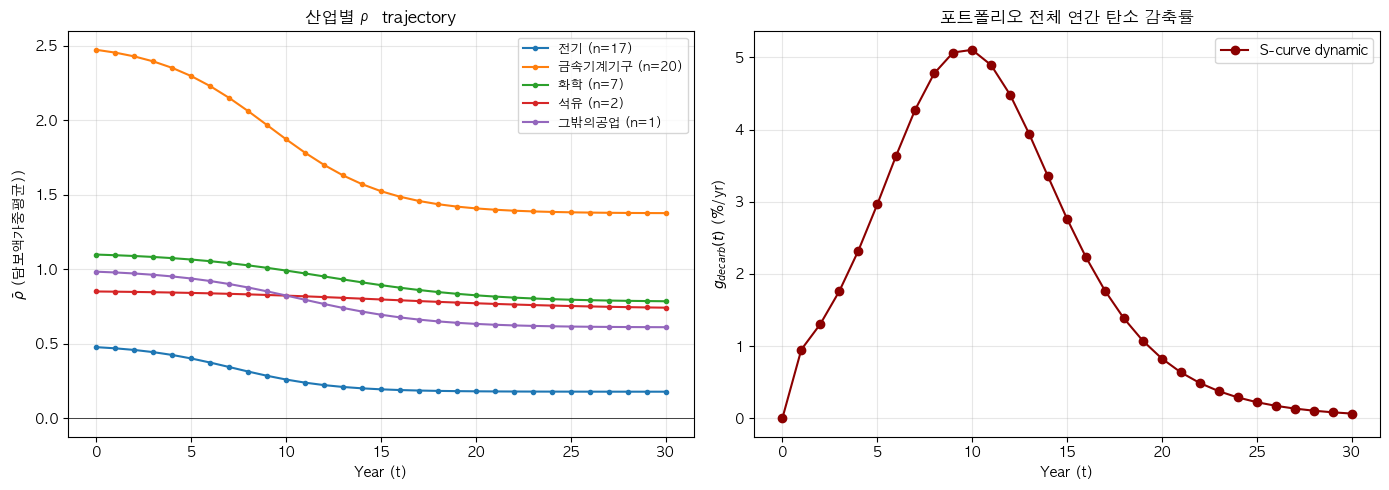


Portfolio ρ̄(0)→ρ̄(30): 1.0266 → 0.5491  (감축률 46.5%)
Portfolio g_decarb peak: 5.10%/yr at t=10


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 산업별 ρ trajectory (담보-가중 평균)
for ind in ['전기', '금속기계기구', '화학', '석유', '그밖의공업']:
    mask = (firms['산업군'] == ind).values
    if mask.sum() == 0: continue
    w = firms.loc[mask, 'E (담보액)'].values
    rho_avg = np.average(rho_mat[mask], axis=0, weights=w)
    axes[0].plot(range(T), rho_avg, marker='o', markersize=3, label=f'{ind} (n={mask.sum()})')
axes[0].set_xlabel('Year (t)'); axes[0].set_ylabel(r'$\bar{\rho}$ (담보액가중평균))')
axes[0].set_title('산업별 ρ trajectory')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3); axes[0].axhline(y=0, color='k', linewidth=0.5)

# Portfolio aggregate g_decarb vs 시트 4%
weights = firms['E (담보액)'].values
rho_bar = np.average(rho_mat, axis=0, weights=weights)
g_portfolio = np.zeros(T)
for t in range(1, T):
    g_portfolio[t] = 1 - rho_bar[t]/rho_bar[t-1] if rho_bar[t-1] > 0 else 0

axes[1].plot(range(T), g_portfolio*100, marker='o', color='darkred', label='S-curve dynamic')
axes[1].set_xlabel('Year (t)'); axes[1].set_ylabel(r'$g_{decarb}(t)$ (%/yr)')
axes[1].set_title('포트폴리오 전체 연간 탄소 감축률')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nPortfolio ρ̄(0)→ρ̄(30): {rho_bar[0]:.4f} → {rho_bar[30]:.4f}  (감축률 {(1-rho_bar[30]/rho_bar[0])*100:.1f}%)')
print(f'Portfolio g_decarb peak: {g_portfolio.max()*100:.2f}%/yr at t={g_portfolio.argmax()}')

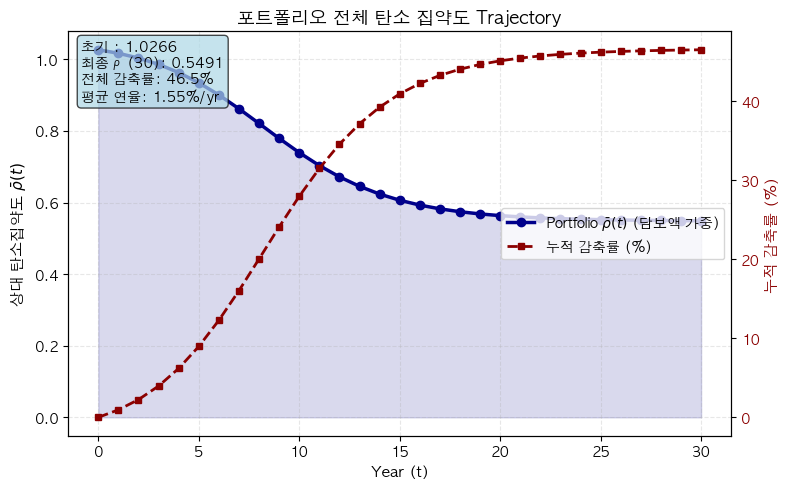


【 포트폴리오 전체 ρ trajectory 】
ρ̄(0) = 1.026645
ρ̄(30) = 0.549070
총 감축률: 46.52%
연평균 감축률: 1.551%/yr


In [20]:
# 포트폴리오 전체 ρ trajectory 시각화
fig, ax = plt.subplots(figsize=(8, 5))

# 포트폴리오 ρ̄(t) 계산 (담보액 가중)
weights = firms['E (담보액)'].values
rho_portfolio = np.average(rho_mat, axis=0, weights=weights)

# 초기값 대비 비율 (감축 진행도)
decarb_progress = (1 - rho_portfolio / rho_portfolio[0]) * 100

ax.plot(range(T), rho_portfolio, marker='o', markersize=6, linewidth=2.5, 
        color='darkblue', label=r'Portfolio $\bar{\rho}(t)$ (담보액 가중)')
ax.fill_between(range(T), rho_portfolio, alpha=0.15, color='darkblue')

# 보조축: 감축률 (%)
ax2 = ax.twinx()
ax2.plot(range(T), decarb_progress, marker='s', markersize=5, linewidth=2, 
         color='darkred', linestyle='--', label='누적 감축률 (%)')
ax2.set_ylabel('누적 감축률 (%)', fontsize=11, color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

ax.set_xlabel('Year (t)', fontsize=11)
ax.set_ylabel(r'상대 탄소집약도 $\bar{\rho}(t)$', fontsize=11)
ax.set_title('포트폴리오 전체 탄소 집약도 Trajectory', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, linestyle='--')

# 범례
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=10)

# 수치 정보 표시
decarb_total = (1 - rho_portfolio[T-1] / rho_portfolio[0]) * 100
ax.text(0.02, 0.98, 
        f'초기 : {rho_portfolio[0]:.4f}\n' +
        f'최종 ρ(30): {rho_portfolio[T-1]:.4f}\n' +
        f'전체 감축률: {decarb_total:.1f}%\n' +
        f'평균 연율: {decarb_total/30:.2f}%/yr',
        transform=ax.transAxes, fontsize=10, verticalalignment='top', 
        horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.show()

print(f'\n【 포트폴리오 전체 ρ trajectory 】')
print(f'ρ̄(0) = {rho_portfolio[0]:.6f}')
print(f'ρ̄(30) = {rho_portfolio[T-1]:.6f}')
print(f'총 감축률: {decarb_total:.2f}%')
print(f'연평균 감축률: {decarb_total/30:.3f}%/yr')

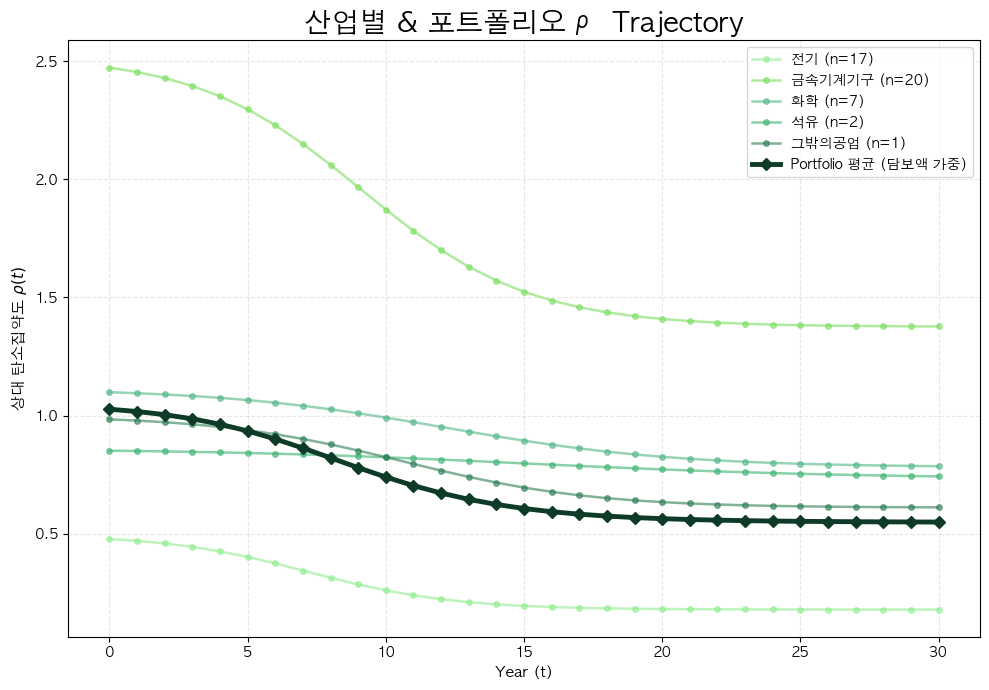

✓ 1번 시각화: 산업별 ρ + 포트폴리오 평균


In [28]:
# 1번 시각화: 산업별 ρ trajectory + 포트폴리오 평균 (함께 표시)
fig, ax = plt.subplots(figsize=(10, 7))

# 색상 맵 (초록색 계열)
colors = {
    '전기': '#90ee90',
    '금속기계기구': '#7bdf5f',
    '화학': '#52b788',
    '석유': '#3bb371',
    '그밖의공업': '#2d7d54'
}

# 산업별 ρ trajectory (담보-가중 평균)
for ind in ['전기', '금속기계기구', '화학', '석유', '그밖의공업']:
    mask = (firms['산업군'] == ind).values
    if mask.sum() == 0: continue
    w = firms.loc[mask, 'E (담보액)'].values
    rho_avg = np.average(rho_mat[mask], axis=0, weights=w)
    ax.plot(range(T), rho_avg, marker='o', markersize=4, linewidth=1.8, 
            color=colors[ind], alpha=0.6, label=f'{ind} (n={mask.sum()})')

# 포트폴리오 평균 (굵은 선 - 제일 진한 초록색)
weights = firms['E (담보액)'].values
rho_portfolio = np.average(rho_mat, axis=0, weights=weights)
ax.plot(range(T), rho_portfolio, marker='D', markersize=6, linewidth=3.5, 
        color='#0d3b28', label='Portfolio 평균 (담보액 가중)', zorder=10)

ax.set_xlabel('Year (t)', fontsize=11)
ax.set_ylabel(r'상대 탄소집약도 $\rho(t)$', fontsize=11)
ax.set_title('산업별 & 포트폴리오 ρ Trajectory', fontsize=20, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print('✓ 1번 시각화: 산업별 ρ + 포트폴리오 평균')


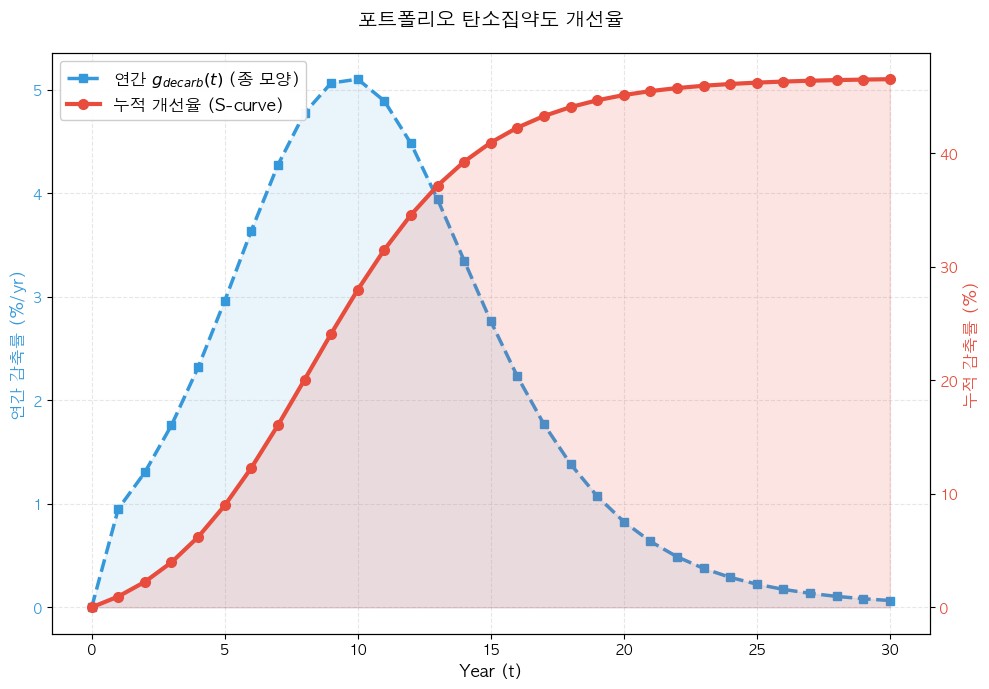

✓ 2번 시각화: 누적 감축률(S-curve) + 연간 감축률(Bell-curve)

【 S-curve vs Bell-curve 대조 】
연간 감축률 최고: 5.10%/yr at t=10
누적 감축률 최종: 46.52%


In [36]:
# 2번 시각화: 누적 감축률(S자 로지스틱) vs 연간 감축률(종 모양 미분)
fig, ax = plt.subplots(figsize=(10, 7))

# Portfolio 레벨 계산
weights = firms['E (담보액)'].values
rho_portfolio = np.average(rho_mat, axis=0, weights=weights)

# 누적 감축률 (S-curve 형태)
decarb_progress = (1 - rho_portfolio / rho_portfolio[0]) * 100

# 연간 감축률 (g_decarb) 
g_portfolio = np.zeros(T)
for t in range(1, T):
    g_portfolio[t] = 1 - rho_portfolio[t]/rho_portfolio[t-1] if rho_portfolio[t-1] > 0 else 0

# 주 축: 연간 감축률 (종 모양 미분, 파란색)
ax.plot(range(T), g_portfolio*100, marker='s', markersize=6, linewidth=2.5, 
        color='#3498DB', linestyle='--', label=r'연간 $g_{decarb}(t)$ (종 모양)', zorder=4)
ax.fill_between(range(T), g_portfolio*100, alpha=0.1, color='#3498DB')

# 보조 축: 누적 감축률 (S-curve, 빨간색)
ax2 = ax.twinx()
ax2.plot(range(T), decarb_progress, marker='o', markersize=7, linewidth=3, 
         color='#E74C3C', label='누적 개선율 (S-curve)', zorder=5)
ax2.fill_between(range(T), decarb_progress, alpha=0.15, color='#E74C3C')

# 축 레이블 및 제목
ax.set_xlabel('Year (t)', fontsize=12, fontweight='bold')
ax.set_ylabel('연간 감축률 (%/yr)', fontsize=12, fontweight='bold', color='#3498DB')
ax2.set_ylabel('누적 감축률 (%)', fontsize=12, fontweight='bold', color='#E74C3C')
ax.set_title('포트폴리오 탄소집약도 개선율', 
             fontsize=14, fontweight='bold', pad=20)

# 축 색상 일치
ax.tick_params(axis='y', labelcolor='#3498DB')
ax2.tick_params(axis='y', labelcolor='#E74C3C')

# 그리드
ax.grid(alpha=0.3, linestyle='--', zorder=0)

# 범례
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=12, framealpha=0.95)

# 주요 수치 정보
peak_t = g_portfolio.argmax()
peak_g = g_portfolio[peak_t] * 100
final_decarb = decarb_progress[-1]


plt.tight_layout()
plt.show()

print('✓ 2번 시각화: 누적 감축률(S-curve) + 연간 감축률(Bell-curve)')
print(f'\n【 S-curve vs Bell-curve 대조 】')
print(f'연간 감축률 최고: {peak_g:.2f}%/yr at t={peak_t}')
print(f'누적 감축률 최종: {final_decarb:.2f}%')
